# Milestone 1 — Data Exploration & Preprocessing
**Project:** Walmart Sales Forecasting
**Dataset:** Walmart Store Sales (45 stores, weekly sales, Feb 2010 – Oct 2012)
**Source:** [Kaggle - Walmart Dataset](https://www.kaggle.com/datasets/yasserh/walmart-dataset)

In this notebook I explore the raw dataset to understand its structure, check data quality, and look at trends/seasonality before doing any modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

pd.set_option('display.max_columns', None)

## 1. Load the data

In [2]:
df = pd.read_csv('../data/raw/Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.shape

(6435, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


The `Date` column is being read as text (`object`), I'll convert it to a proper datetime later.

## 2. Data quality check (missing values, duplicates)

In [5]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

Good news: no missing values and no duplicate rows. This dataset is already fairly clean, so the main work here will be converting types and engineering new features rather than heavy cleaning.

## 3. Fix data types

In [7]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Store'] = df['Store'].astype('category')
df['Holiday_Flag'] = df['Holiday_Flag'].astype('category')

df.dtypes

Store                 category
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag          category
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [8]:
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Number of stores:', df['Store'].nunique())
print('Number of weeks:', df['Date'].nunique())

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of stores: 45
Number of weeks: 143


So we have **45 stores** with weekly sales data over **143 weeks** (about 2.7 years). Let's check if the weeks are continuous (no gaps).

In [9]:
weekly_dates = df['Date'].drop_duplicates().sort_values()
weekly_dates.diff().value_counts()

Date
7 days    142
Name: count, dtype: int64

Every gap is exactly 7 days, so the data is a clean, continuous weekly series with no missing weeks. That's helpful for the forecasting step later.

## 4. Sales trend over time

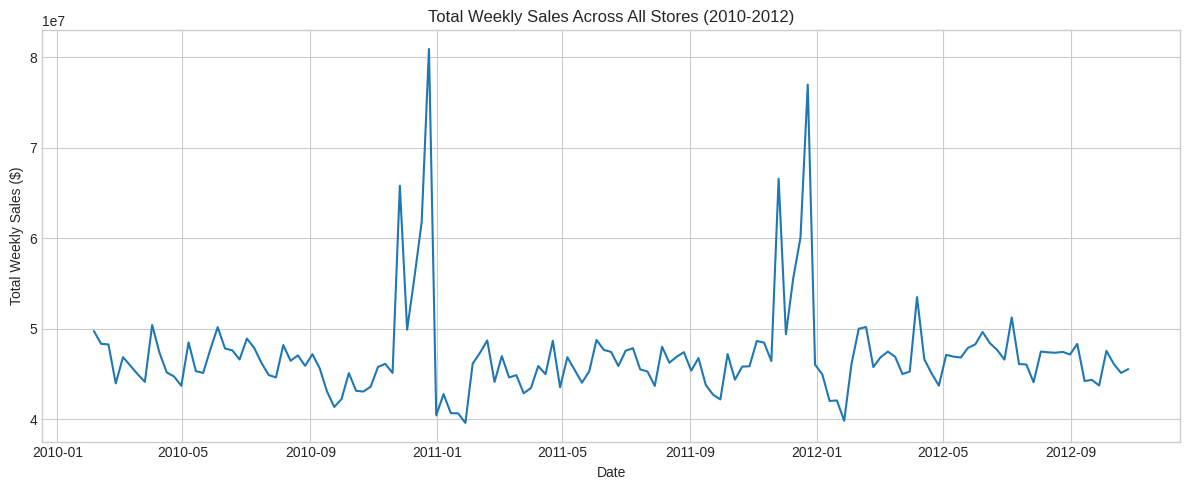

In [10]:
total_weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(total_weekly_sales['Date'], total_weekly_sales['Weekly_Sales'], color='#1f77b4')
ax.set_title('Total Weekly Sales Across All Stores (2010-2012)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales ($)')
plt.tight_layout()
plt.savefig('../reports/figures/01_total_sales_trend.png', dpi=110)
plt.show()

There are clear spikes around the end of each year (Nov/Dec) — most likely Thanksgiving, Black Friday, and Christmas. There's no obvious long-term upward or downward trend across the 2.7 years, sales mainly move with seasonal/holiday effects.

## 5. Distribution of weekly sales

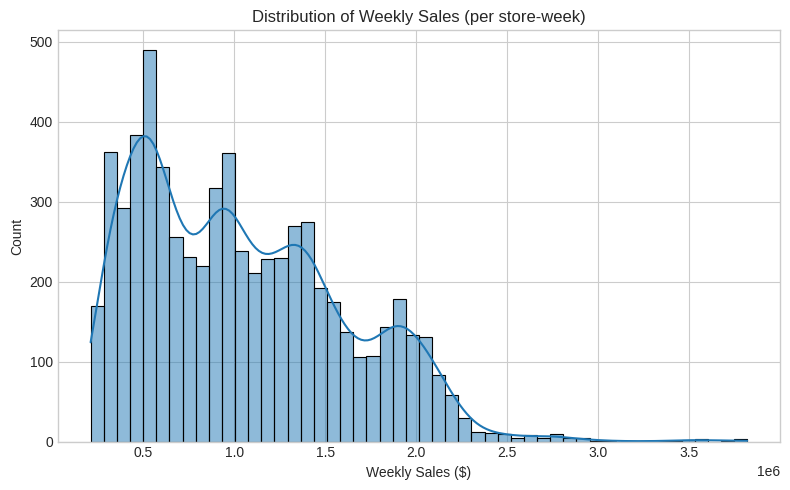

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, ax=ax, color='#1f77b4')
ax.set_title('Distribution of Weekly Sales (per store-week)')
ax.set_xlabel('Weekly Sales ($)')
plt.tight_layout()
plt.savefig('../reports/figures/02_sales_distribution.png', dpi=110)
plt.show()

df['Weekly_Sales'].describe()

The distribution is right-skewed with a long tail — most store-weeks fall between ~\$0.5M and \$1.5M, but a handful of large stores pull the tail up to over \$3M. This makes sense since store sizes vary a lot (45 different stores).

## 6. Correlation between sales and other factors

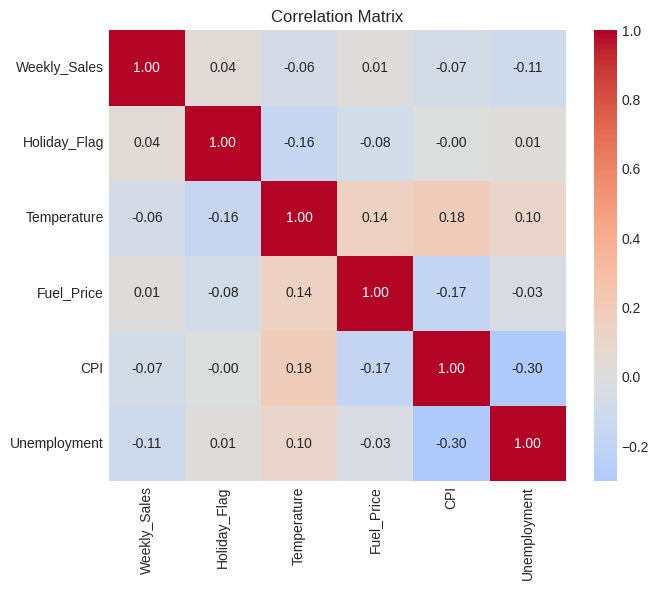

In [12]:
corr_cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_df = df[corr_cols].copy()
corr_df['Holiday_Flag'] = corr_df['Holiday_Flag'].astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/03_correlation_heatmap.png', dpi=110)
plt.show()

None of the economic/weather variables show a strong linear correlation with `Weekly_Sales` (all under 0.11 in absolute value). This is a common finding with this dataset — it suggests that **Store** and **time/seasonality** (week of year, holidays) matter a lot more for predicting sales than CPI, fuel price, temperature or unemployment on their own. I'll keep this in mind for feature engineering and modeling later — store-level and date-level features will probably be more useful than these economic indicators alone.

## 7. Holiday vs non-holiday weeks

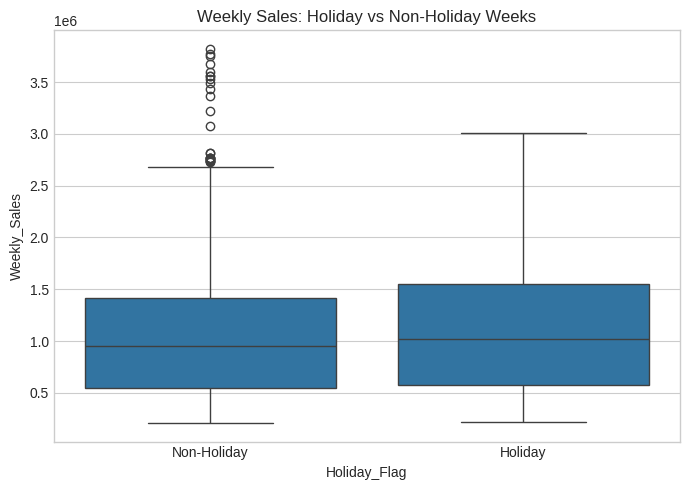

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Holiday', 'Holiday'])
ax.set_title('Weekly Sales: Holiday vs Non-Holiday Weeks')
plt.tight_layout()
plt.savefig('../reports/figures/04_holiday_boxplot.png', dpi=110)
plt.show()

df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday weeks average about **\$1.12M** vs **\$1.04M** for non-holiday weeks — roughly an 8% lift. The effect is real but smaller than I expected given how visible the end-of-year spikes were in the trend chart. That's probably because the holiday flag only marks the exact holiday week, while the actual sales build-up (e.g. Black Friday shopping) can spread across a few surrounding weeks too.

## 8. Sales by store

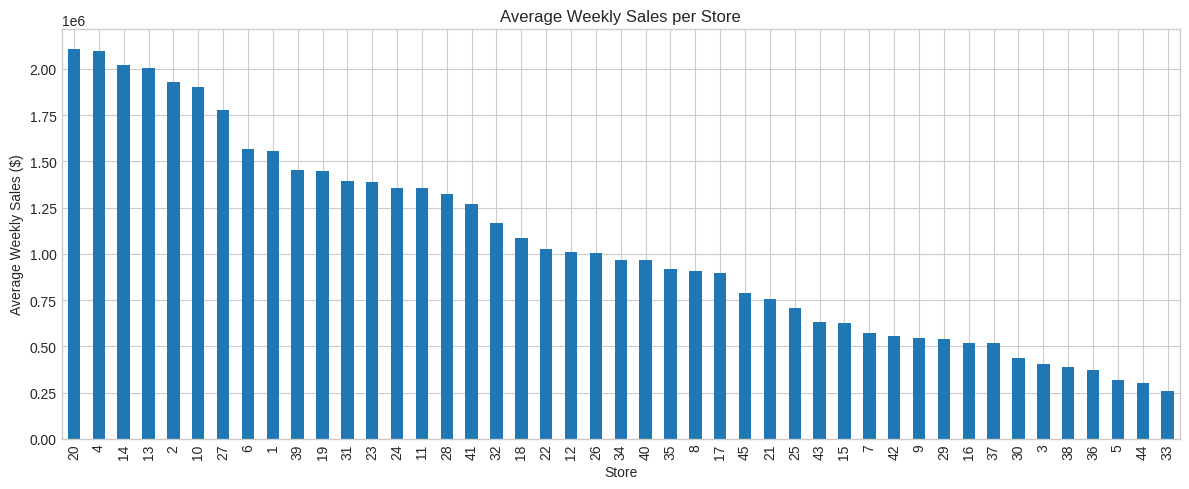

Top 3 stores by avg sales:
Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
Name: Weekly_Sales, dtype: float64

Bottom 3 stores by avg sales:
Store
5     318011.810490
44    302748.866014
33    259861.692028
Name: Weekly_Sales, dtype: float64


In [14]:
store_avg_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
store_avg_sales.plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title('Average Weekly Sales per Store')
ax.set_xlabel('Store')
ax.set_ylabel('Average Weekly Sales ($)')
plt.tight_layout()
plt.savefig('../reports/figures/05_store_avg_sales.png', dpi=110)
plt.show()

print('Top 3 stores by avg sales:')
print(store_avg_sales.head(3))
print()
print('Bottom 3 stores by avg sales:')
print(store_avg_sales.tail(3))

There's a huge gap between stores — the top store (Store 20) averages around \$2.1M/week while the smallest (Store 33) averages only ~\$260K/week, about 8x less. This confirms that **Store** is going to be one of the most important features for the model, since store size/location clearly drives a big part of the sales level.

## 9. Seasonality check (monthly pattern)

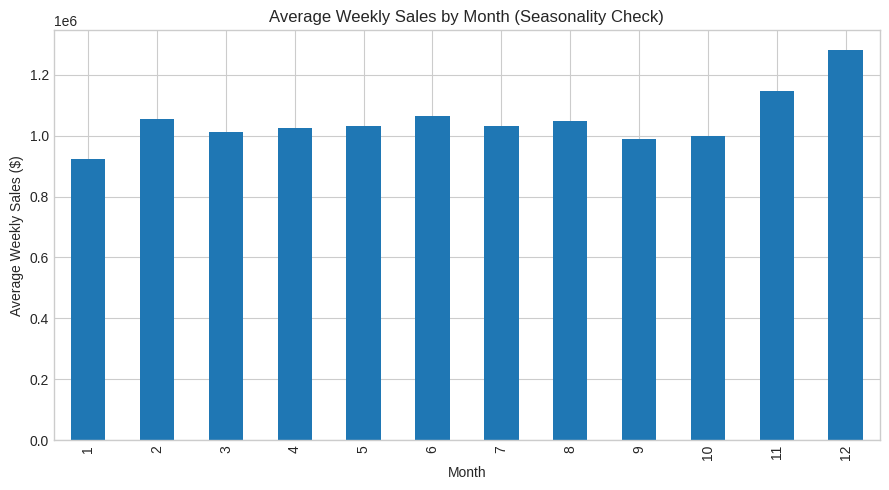

Month
12    1.281864e+06
11    1.147266e+06
6     1.064325e+06
2     1.053200e+06
8     1.048017e+06
7     1.031748e+06
5     1.031714e+06
4     1.026762e+06
3     1.013309e+06
10    9.996321e+05
9     9.893353e+05
1     9.238846e+05
Name: Weekly_Sales, dtype: float64

In [15]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Weekly_Sales'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
monthly_avg.plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title('Average Weekly Sales by Month (Seasonality Check)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Weekly Sales ($)')
plt.tight_layout()
plt.savefig('../reports/figures/06_monthly_seasonality.png', dpi=110)
plt.show()

monthly_avg.sort_values(ascending=False)

December is clearly the strongest month (~\$1.28M avg) and January is the weakest (~\$0.92M avg) — about a 39% difference. This confirms the seasonal spike I saw in the trend chart is mainly a December/holiday-season effect, with a drop right after in January once the holiday shopping is over.

## 10. Feature engineering

Based on what I found above, I'll add a few time-based features that should help the models later (especially Store, month and holiday-related features):

In [16]:
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Date'].dt.dayofweek

df[['Date', 'Year', 'Month', 'Week', 'Day_of_Week', 'Holiday_Flag']].head()

,Date,Year,Month,Week,Day_of_Week,Holiday_Flag
0,2010-02-05,2010,2,5,4,0
1,2010-02-12,2010,2,6,4,1
2,2010-02-19,2010,2,7,4,0
3,2010-02-26,2010,2,8,4,0
4,2010-03-05,2010,3,9,4,0


## 11. Save the processed dataset

In [17]:
df.to_csv('../data/processed/walmart_clean.csv', index=False)
print('Saved processed dataset:', df.shape)

Saved processed dataset: (6435, 12)


## Summary of findings

- The dataset is clean: **no missing values, no duplicates**, and the 143 weeks are continuous with no gaps.
- Sales are **right-skewed**, mainly driven by differences between stores (up to 8x between the biggest and smallest store).
- **Store** is the single most important factor for sales level — much more than economic indicators.
- CPI, Unemployment, Fuel Price and Temperature all have **weak correlation** with sales (|r| < 0.11).
- There's a clear **holiday effect** (+8% on holiday weeks) and a strong **December seasonality** (~39% higher than January).
- Added `Year`, `Month`, `Week`, `Day_of_Week` as new features to capture this seasonality for modeling.

**Next step (Milestone 2):** deeper visual analysis / dashboard, then move to forecasting models in Milestone 3, using Store and time-based features as the main predictors.